# VOCALS-REx retrieval with pydisort_riccati_jax

The ultimate goal is to **retrieve an effective-radius profile $r_e(\tau)$** from VOCALS-REx marine stratocumulus, using the fully differentiable chain

$$ r_e(\tau)\xrightarrow{\;\texttt{miejax\_lite}\;}\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\xrightarrow{\;\texttt{pydisort\_riccati\_jax}\;} u^{+}(\tau{=}0,\mu,\phi). $$

VOCALS stratocumulus has $r_e\approx 4$–$17\,\mu\mathrm{m}$, observed in the MODIS bands 0.645 / 1.64 / **2.13** µm (2.13 µm is the most absorbing, where $\omega<1$ carries the size signal), with $\tau$ up to $\sim30$ over a low-albedo ocean ($\rho\approx0.05$). This notebook assumes the [intro notebook](./riccati_solver_intro.ipynb) and that [`miejax_lite`](../../miejax_lite/README.md) is installed (`pip install -e ../miejax_lite`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate
from miejax_lite import (
    mie_legendre_precompute, build_re_table, select_channel, table_lookup,
)

## 1. Mie optical properties from $r_e(\tau)$

We model an **adiabatic** cloud whose effective radius grows from cloud base ($\tau{=}$ `tau_bot`) toward top. The optics come from a **precomputed $r_e\to(\omega,\text{Leg\_coeffs})$ interpolation table** (`build_re_table` / `table_lookup`): full Mie inside the solver's ODE never finishes compiling, so we tabulate it once over the physical size range and do an $O(1)$, differentiable linear lookup in the hot path. The table is built at high radius-integration resolution for a ripple-free map, over a grid $[2,25]\,\mu$m spanning the VOCALS-REx in-cloud $r_e$ range with margin (design: [`optics_table_map.md`](../../miejax_lite/docs/optics_table_map.md)). We wrap the lookup in the `*_func(tau)` callables the solver expects.

The profile is written so that $r_e^3$ is **linear** in optical depth (adiabatic: $r_e^3\propto$ LWC). This keeps $r_e\ge r_\text{base}$ and $dr_e/d\tau$ finite — the textbook $r_e\propto(1-\tau/\tau_\text{bot})^{1/3}$ has an infinite-slope cube-root cusp at cloud base that exhausts the adaptive ODE solver (real VOCALS-REx profiles are finite-slope).

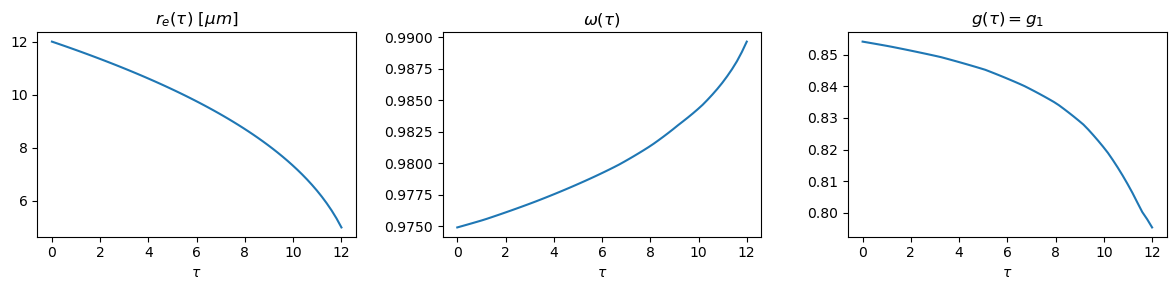

In [2]:
wavelength, v_eff = 2.13, 0.10           # MODIS band 7 (microns), gamma width

tau_bot = 12.0
NQuad, NLeg, NLeg_all = 16, 16, 32       # streams; NLeg_all > NLeg feeds delta-M / TMS
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)

# Optics interpolation table r_e -> (omega, Leg_coeffs), built once (offline,
# high n_radii -> ripple-free). Full Mie inside the ODE never finishes compiling;
# the table makes the optics O(1) and keeps r_e -> (omega, Leg) differentiable
# (table-slope Jacobian). select_channel picks the (single) MODIS band exactly.
opt = select_channel(
    build_re_table([wavelength], 2.0, 25.0, 32, v_eff, precomp, n_radii=600), 0)

# Adiabatic r_e(tau): grows from base (tau=tau_bot) to top (tau=0). r_e**3 is
# linear in optical depth, so r_e stays >= re_base and dr_e/dtau is finite (no
# cube-root cusp at cloud base -- which would otherwise exhaust the ODE solver).
re_top, re_base = 12.0, 5.0              # microns
def r_e_of_tau(tau, re_top=re_top, re_base=re_base):
    return (re_base ** 3 + (re_top ** 3 - re_base ** 3) * (1 - tau / tau_bot)) ** (1 / 3)

def optics(tau, re_top=re_top, re_base=re_base):
    return table_lookup(opt, r_e_of_tau(tau, re_top, re_base))

omega_func      = lambda tau: optics(tau)[0]
Leg_coeffs_func = lambda tau: optics(tau)[1]

tau_plot = jnp.linspace(0, tau_bot, 60)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(tau_plot, [r_e_of_tau(t) for t in tau_plot]); ax[0].set_title(r'$r_e(\tau)\ [\mu m]$')
ax[1].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[1].set_title(r'$\omega(\tau)$')
ax[2].plot(tau_plot, [Leg_coeffs_func(t)[1] for t in tau_plot]); ax[2].set_title(r'$g(\tau)=g_1$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Forward model: ToA radiance

Solve, then interpolate to the satellite viewing geometry. This `forward` function — radiance as a function of the profile parameters — is the object we will both evaluate and differentiate.

In [3]:
mu0, I0, phi0 = 0.6, 1.0, 0.0           # solar geometry
mu_obs, phi_obs = 0.5, pi               # viewing geometry
BDRF = [0.05 / pi]                       # ocean surface

def forward(re_top, re_base):
    om  = lambda tau: optics(tau, re_top, re_base)[0]
    Leg = lambda tau: optics(tau, re_top, re_base)[1]
    mu_arr_pos, flux_up, u0, u_func, _ = pydisort_riccati_jax(
        tau_bot, om, Leg, NQuad, mu0, I0, phi0,
        tol=1e-3, BDRF_Fourier_modes=BDRF,                    # float32-safe production tol
        delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)  # forward-peak fix (OUTSTANDING A)
    return interpolate(u_func, mu_arr_pos)(mu_obs, phi_obs)

I_obs = forward(re_top, re_base)
print('ToA radiance at (mu_obs, phi_obs):', float(I_obs))

ToA radiance at (mu_obs, phi_obs): 0.2726891040802002


## 3. Retrieval Jacobian via autodiff

Because the whole chain is JAX-traceable, the sensitivity of the observed radiance to the profile parameters is a single `jax.grad` — no finite differences, no perturbing the solver. This $\partial I/\partial r_e$ is the building block of the retrieval's Gauss–Newton / optimal-estimation step.

*Parameters must enter through `omega_func`/`Leg_coeffs_func`; `tau_bot`, `mu0`, `NQuad` are validated in NumPy and are not differentiable. Finite-difference validation of these gradients lives in the float64 test suite (`pytest -m float64`); in float32 a bare FD is dominated by the solver's tolerance floor, so we don't reproduce it in this demonstration.*

In [4]:
dI_dre_top, dI_dre_base = jax.grad(forward, argnums=(0, 1))(re_top, re_base)
print('dI/d(r_e top)  =', float(dI_dre_top))
print('dI/d(r_e base) =', float(dI_dre_base))

dI/d(r_e top)  = 0.015004666522145271
dI/d(r_e base) = -0.00023303617490455508


## 4. Toward a multi-band retrieval

A real retrieval stacks several MODIS bands (0.645 µm constrains $\tau$, 2.13 µm constrains $r_e$) and minimises a cost $\;J(\boldsymbol\theta)=\sum_b \lVert I_b^{\text{obs}}-F_b(\boldsymbol\theta)\rVert^2 + \text{(prior)}$ over the $r_e(\tau)$ parameters $\boldsymbol\theta$.
 The gradient $\nabla_{\boldsymbol\theta} J$ is assembled from the per-band Jacobians above via `jax.grad`, and fed to an optimiser (`jaxopt`, `optax`, or a hand-rolled Gauss–Newton step). Stacking bands is just building the table at several wavelengths — `build_re_table([0.645, 1.64, 2.13], …)` and `select_channel` per band; a hyperspectral instrument instead builds on a dense, uniform $\lambda$ grid and `slice_wavelength`-interpolates to each channel.

**Performance & scope notes.** The forward model's cost is dominated by the number of adaptive Riccati steps (~35 for $\tau{=}30$); loosen `tol` in the retrieval loop and tighten only for the final fit. The default float32 is adequate against VOCALS measurement noise (10–20 %); enable `jax_enable_x64` for finite-difference gradient checks. Delta-M scaling + the Nakajima–Tanaka TMS correction are **enabled here** (`delta_M_scaling=True, NT_cor=True`, with `NLeg_all=32` untruncated moments) so the forward-peaked-Mie ToA radiance stays non-negative (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A); memory-efficient discrete adjoints remain deferred.

## 5. A real VOCALS-REx profile (the retrieval *truth*)

We now retrieve $r_e(\tau)$ from a genuine VOCALS-REx marine-stratocumulus
penetration. `vocals_io` reads a C-130 flight (CDP probe, 1 Hz), finds clean
vertical in-cloud profiles, and returns each as $(\tau, r_e)$ with the
cloud-optical-depth integration $\tau(z)=\pi\!\int Q_{\rm ext}\,r_e^2 N_c\,dz$
from cloud top down. We start with a **thin** profile ($\tau_{\rm bot}\!\approx\!1.2$);
$\tau_{\rm bot}$ and the base radius $r_e(\tau_{\rm bot})$ are taken as **known**
(the two hardest quantities to retrieve in thick cloud — deferred).

RF11: tau_bot=1.21, r_e 5.8-8.7 um, n=20


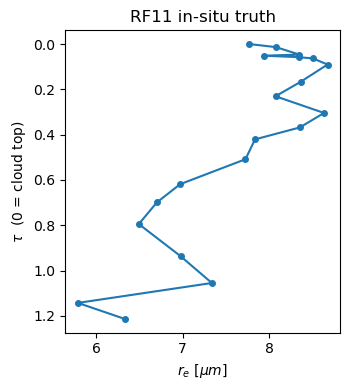

In [5]:
import jax
jax.clear_caches()   # free the intro cells' compiled executables before the (memory-heavy) retrieval

import vocals_io as vio
import retrieval_oe as roe
from miejax_lite import mie_legendre_precompute, build_re_table, select_channel

DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
truth = vio.pick_profile(vio.load_all_profiles(DATA), target_tau=1.0)
print(f'{truth.flight}: tau_bot={truth.tau_bot:.2f}, '
      f'r_e {truth.r_e.min():.1f}-{truth.r_e.max():.1f} um, n={truth.tau.size}')

fig, ax = plt.subplots(figsize=(3.6, 4))
ax.plot(truth.r_e, truth.tau, 'o-', ms=4)
ax.invert_yaxis()
ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$  (0 = cloud top)')
ax.set_title(f'{truth.flight} in-situ truth')
plt.tight_layout()

## 6. Multi-band, multi-angle forward model

The observation stacks bidirectional reflectance $R=\pi u/(\mu_0 I_0)$ over an
**absorption ladder** of bands $\times$ **view angles**. The bands (1.24, 2.13 µm)
span weak$\to$strong water absorption, so their weighting functions peak at
different depths (Platnick 2000); the multiple view angles (nadir to ~60°, within
the PACE/SPEXone envelope and the back-scatter regime away from the forward
aureole) add vertical information — our lever beyond the mostly-nadir MODIS
literature.

Two forward-model settings matter (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A′, §H):
**`NLeg_all=128`** — the Nakajima–Tanaka single-scatter correction reconstructs the
phase function as a truncated Legendre sum, and a Mie *cloud* needs ~60+ moments
(32 gives a Gibbs-oscillating $p_{\rm full}$ that wrecks the thin-cloud, single-
scatter-dominated off-nadir radiance). **`NFourier=8`** (fixed, no in-loop Cauchy):
after delta-M the azimuthal modes decay fast, so 8 reproduces the converged radiance
to <1 % while keeping the reverse-mode Jacobian within memory.

In [6]:
bands = [1.24, 2.13]                         # weak -> strong absorption ladder
NQuad, NLeg_all, v_eff = 16, 128, 0.10
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)
table = build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600)
opt_bands = [select_channel(table, i) for i in range(len(bands))]

mu0, I0, phi0 = 0.6, 1.0, 0.0
view_mu = np.array([0.90, 0.65, 0.50])      # ~25, 50, 60 deg view zenith
view_phi = np.array([pi, pi, pi])           # principal plane, back-scatter
BDRF = [[0.05 / pi]] * len(bands)           # dark ocean

fwd = roe.RetrievalForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=truth.tau_bot, r_base=truth.r_base,
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=BDRF)
print(f'{len(bands)} bands x {view_mu.size} angles = {fwd.m} observations; '
      f'NLeg_all={NLeg_all}, NFourier=8 (fixed)')

2 bands x 3 angles = 6 observations; NLeg_all=128, NFourier=8 (fixed)


## 7. OSSE observation $y = F(x_{\rm true})$

We generate a **noiseless** synthetic observation by running the forward model on
the dense in-situ truth profile (an Observing System Simulation Experiment). Noise
is deferred by design — the pipeline is being built toward operational PACE data;
the assumed radiometric error $S_\varepsilon$ still weights the cost and sets the
posterior uncertainty.

In [7]:
y = roe.osse_observation(fwd, truth.tau, truth.r_e)   # noiseless
print('observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]')
print(np.round(y.reshape(len(bands), view_mu.size), 4))
assert np.all(y > 0), 'unphysical (negative) reflectance'

observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]
[[0.1096 0.2464 0.2474]
 [0.1062 0.2174 0.2795]]


## 8. Retrieval grid: a QRCP-trimmed subset of the adaptive ODE grid

The retrieval grid is **not** prescribed a-priori. The L-stable solver places its
adaptive $\tau$-steps by genuine variation of the Riccati state, making that grid a
trustworthy *superset* of the retrieval-informative points (`DESIGN_DECISIONS.md`
§3). We form the ToA sensitivity $\partial y/\partial r_e(\tau_j)$ on that pool by
autodiff and rank the nodes by independent information with QR-with-column-pivoting,
keeping a small subset (here $k=4$, cloud top always included). The deep BoA steps
— densest but least informative — are pruned by sensitivity.

In [8]:
tau_coarse = np.linspace(0.0, truth.tau_bot, 6)[:-1]      # adiabatic first guess grid
x0, _ = roe.make_adiabatic_prior(tau_coarse, truth.tau_bot, truth.r_base,
                                 r_top_prior=truth.r_top)
fwd.calibrate(x0, tau_coarse)
k_active = 4
tau_grid, re_grid, info = roe.select_retrieval_grid(fwd, x0, tau_coarse, k_active)
print(f'ODE pool: {info["tau_pool"].size} nodes  ->  QRCP-selected {k_active}: '
      f'tau = {np.round(tau_grid, 3)}')

ODE pool: 20 nodes  ->  QRCP-selected 4: tau = [0.    0.032 0.311 0.652]


## 9. Prior: adiabatic mean + Bayesian–Tikhonov covariance

The prior is the **adiabatic** $r_e^3$-linear profile (known base $\to$ prior top)
with a **correlated** Gaussian covariance
$S_a[i,j]=\sigma_i\sigma_j\exp(-|\tau_i-\tau_j|/\ell)$: depth-increasing $\sigma$
(top tight ~3 µm, base loose ~10 µm — the weighting-function argument that deep
$r_e$ is poorly constrained), and an off-diagonal correlation length $\ell$ that
*is* the Bayesian–Tikhonov smoothness term. The interface is **pluggable** — a
data-learned prior (VOCALS ensemble / EOF) would slot in with the same signature.

In [9]:
prior_builder = lambda tn: roe.make_adiabatic_prior(
    tn, truth.tau_bot, truth.r_base, r_top_prior=truth.r_top,
    sigma_top=3.0, sigma_base=10.0)
x_a, Sa = prior_builder(tau_grid)

# observation error covariance: assumed ~3% radiometric (floor for tiny R)
sigma_obs = 0.03 * np.maximum(np.abs(y), 0.02)
Se = np.diag(sigma_obs ** 2)
print('prior  x_a   =', np.round(x_a, 2))
print('prior  sigma =', np.round(np.sqrt(np.diag(Sa)), 1), 'um (top->base)')

prior  x_a   = [7.77 7.74 7.45 7.07]
prior  sigma = [3.  3.2 4.8 6.8] um (top->base)


## 10. Optimal estimation with lagged re-meshing

Rodgers Gauss–Newton minimises
$J(x)=\tfrac12\|y-F(x)\|^2_{S_\varepsilon^{-1}}+\tfrac12\|x-x_a\|^2_{S_a^{-1}}$.
The Jacobian $K=\partial y/\partial x$ is exact reverse-mode autodiff through the
jitted solver (no finite differences). An **outer loop** re-selects the retrieval
grid by QRCP at the *current* estimate and re-maps the state and prior onto the new
nodes — correcting the first-guess node placement. Because the node *count* is fixed,
relocating them is recompile-free r-refinement.

In [10]:
res = roe.gauss_newton_oe(
    fwd, y, tau_grid, x_a, Sa, Se, n_iter=10, lm=1e-2, xtol=2e-3,
    n_outer=2, k_active=k_active, prior_builder=prior_builder)

truth_at = np.interp(res.tau_nodes, truth.tau, truth.r_e)
print(f'converged={res.converged}, '
      f'cost {res.cost_history[0]:.2e} -> {res.cost_history[-1]:.2e}, '
      f'||y-F|| = {np.linalg.norm(res.y - res.Fx):.2e}')
print(f'final grid tau = {np.round(res.tau_nodes, 3)}')
print(f'  retrieved = {np.round(res.x, 2)}')
print(f'  truth     = {np.round(truth_at, 2)}')
print(f'  prior x_a = {np.round(res.x_a, 2)}')

converged=True, cost 1.01e+00 -> 5.19e-02, ||y-F|| = 1.37e-03
final grid tau = [0.    0.08  0.309 0.519]
  retrieved = [8.43 8.5  8.11 7.52]
  truth     = [7.77 8.61 8.61 7.65]
  prior x_a = [7.77 7.69 7.46 7.23]


## 11. Uncertainty quantification — the deliverable

The posterior covariance $\hat S=(K^{\!\top}S_\varepsilon^{-1}K+S_a^{-1})^{-1}$
gives the retrieval error $\sqrt{\mathrm{diag}\,\hat S}$; the **averaging kernel**
$A=\hat S\,K^{\!\top}S_\varepsilon^{-1}K$ shows *where in $\tau$* each retrieved
level draws its information, and $\mathrm{DOFS}=\mathrm{tr}\,A$ counts the
independent pieces of profile information. For a thin cloud with a handful of
channels we expect a small DOFS and kernels weighted toward cloud top — the
retrieved profile sits within $\pm1\sigma$ of the in-situ truth, with the deep
nodes legitimately prior-influenced.

*The retrieved/prior curves are drawn with `fwd.profile()` — the **same parameterisation the forward model integrated** (the `_re_of_tau` lever in `retrieval_oe`), extended to the assumed-known base (red). The inter-node interpolation is **part of the forward map**, not a post-hoc display choice, so the curve mirrors $F(x)$ exactly. The default class is **$r_e^3$-linear (adiabatic)** — physically natural and coherent with the prior; **linear** (impute-nothing) and **PCHIP** (C¹, for higher-DOF regimes such as thicker clouds) are recorded alternatives, see [`OUTSTANDING.md`](./OUTSTANDING.md) §B′. Flipping the lever changes the retrieval and this plot consistently.*

DOFS = 2.12   (independent pieces of profile information)
retrieval 1-sigma error = [1.68 1.49 1.44 0.93] um


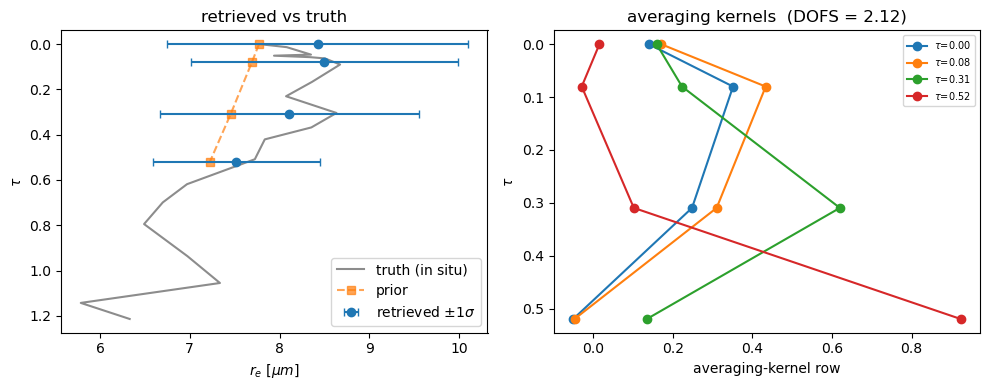

In [11]:
post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
print(f'DOFS = {post.dofs:.2f}   (independent pieces of profile information)')
print(f'retrieval 1-sigma error = {np.round(post.error, 2)} um')

# Draw the retrieved/prior profiles via fwd.profile() -- the SAME parameterisation
# the forward integrated (the jnp.interp lever in retrieval_oe._re_of_tau), so the
# curve mirrors F(x) by construction rather than re-interpolating post-hoc.
tau_d = np.linspace(0.0, truth.tau_bot, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(truth.r_e, truth.tau, '-', color='k', alpha=0.4, label='truth (in situ)')
ax[0].plot(fwd.profile(res.x_a, res.tau_nodes, tau_d), tau_d, '--', color='C1',
           alpha=0.5, label='prior')
ax[0].plot(fwd.profile(res.x, res.tau_nodes, tau_d), tau_d, '-', color='C0',
           alpha=0.8, label='retrieved (forward param.)')
ax[0].errorbar(res.x, res.tau_nodes, xerr=post.error, fmt='o', color='C0', capsize=3,
               label=r'nodes $\pm1\sigma$')
ax[0].plot(truth.r_base, truth.tau_bot, 'o', color='red', ms=9, zorder=5,
           label=r'known base $(\tau_{bot}, r_{base})$')
ax[0].invert_yaxis()
ax[0].set_xlabel(r'$r_e\ [\mu m]$'); ax[0].set_ylabel(r'$\tau$')
ax[0].legend(fontsize=8); ax[0].set_title('retrieved vs truth')

for i in range(res.tau_nodes.size):
    ax[1].plot(post.A[i], res.tau_nodes, 'o-', label=fr'$\tau$={res.tau_nodes[i]:.2f}')
ax[1].invert_yaxis()
ax[1].set_xlabel('averaging-kernel row'); ax[1].set_ylabel(r'$\tau$')
ax[1].set_title(f'averaging kernels  (DOFS = {post.dofs:.2f})')
ax[1].legend(fontsize=7)
plt.tight_layout()

## 12. Notes and next steps

- **Deliverable 1 (UQ)** is the figure above: the posterior error and averaging
  kernels quantify, under the adiabatic prior, exactly which part of $r_e(\tau)$ the
  multi-band/multi-angle measurement constrains and which is prior-dominated.
- **Deliverable 2** is the recovery of a real VOCALS-REx profile (thin, $\tau\approx1$).
  A **thicker** profile ($\tau\gtrsim10$) — where the deep nodes become strongly
  prior-dominated and conditioning is harder — is the natural next case (paused for
  discussion).
- **Forward-model follow-ups** (tracked in `OUTSTANDING.md`): demote the Cauchy
  azimuthal test to an offline diagnostic and `vmap` the Fourier modes (§H, lifts the
  NQuad ceiling and the Jacobian memory), and add a thin-cloud Mie off-nadir
  physical-plausibility test (§A′). The prior is pluggable for a future learned prior.